# Early Diabetes Detection Using Symptoms

### <u>Problem Statement</u>
Inadequate insulin production or inresponsiveness of body cells to insulin may cause an increase in blood glucose in the body of a person and causing diabetes. Diabetes could cause many other complications, such as loss of vision, kidney infection, and heart problems. Hence, early detection of diabetes can help the patients to keep their sugar levels under control by taking healthy diet with required drugs. 

### <u>Main Objectives</u>
To build an efficient model that can help the patients to detect if they have diabetes. <br>



In [1]:
from IPython.display import display, HTML

html_content = """
<h3>Dataset Source</h3>
<p>
This dataset is originally from 
<a href="https://archive.ics.uci.edu/ml/datasets/Early+stage+diabetes+risk+prediction+dataset" target="_blank">
UCI Machine Learning Repository
</a>.
</p>
<p>
It contains the sign and symptom data of newly diabetic or potentially diabetic patients.
</p>
"""

display(HTML(html_content))

In [2]:
!pip install xgboost imbalanced-learn statsmodels seaborn

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.2 MB/s eta 0:01:25
   ---------------------------------------- 0.5/101.7 MB 1.2 MB/s eta 0:01:25
   ---------------------------------------- 0.8/101.7 MB 1.2 MB/s eta 0:01:28
   ---------------------------------------- 1.0/101.7 MB 986.7 kB/s eta 0:01:42
   ---------------------------------------- 1.0/101.7 MB 986.7 kB/s eta 0:01:42
    --------------------------------------- 1.3/101.7 MB 919.0 kB/s eta 0:01:50
    --------------------------------------- 1.3/101.7 MB 919.0 kB/s eta 0:01:50
    --------------------------------------- 1.6/101.7 MB 830.6 kB/s eta 0:02:01
    --------------------------------------- 1.6/101.7 MB 830.6 kB/s eta 0:02:01
    

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 11.3.0 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [77]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline

import seaborn as sns
sns.set_style('darkgrid')

from IPython.display import display, HTML

# Stats
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.weightstats import ztest
from scipy import stats
from numpy import interp

# Utilities
from collections import Counter

# Sklearn & Imblearn
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as imbpipeline


# from pipelinehelper import PipelineHelper

from sklearn.compose import ColumnTransformer

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN, SMOTETomek

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split


from sklearn.metrics import recall_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression 
from sklearn.neighbors import KNeighborsClassifier  
from sklearn.tree import DecisionTreeClassifier as DT 
from sklearn.ensemble import RandomForestClassifier as RF 
from sklearn.ensemble import AdaBoostClassifier


# !pip install xgboost
from xgboost import XGBClassifier 

from sklearn.naive_bayes import GaussianNB as GB  
from sklearn.svm import SVC  

In [78]:
diabetes_df=pd.read_csv("C:\\Users\\tanis\\Downloads\\diabetes_data_upload.csv")
diabetes_df.head()


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


# Descriptive Statistics

In [79]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class               520 no

### From the result above, only 'Age' column has numerical values as its input, while other columns have categorical inputs.

In [80]:
diabetes_df.columns = diabetes_df.columns.str.lower()

In [81]:
diabetes_df.sample(5)

,age,gender,polyuria,polydipsia,sudden weight loss,weakness,polyphagia,genital thrush,visual blurring,itching,irritability,delayed healing,partial paresis,muscle stiffness,alopecia,obesity,class
98,35,Female,Yes,Yes,No,No,No,No,Yes,No,No,No,No,No,Yes,No,Positive
513,62,Female,Yes,Yes,Yes,Yes,No,No,Yes,No,No,No,Yes,No,No,Yes,Positive
73,38,Female,Yes,Yes,Yes,Yes,Yes,No,No,No,No,No,Yes,No,No,No,Positive
323,44,Male,Yes,No,Yes,Yes,No,Yes,No,Yes,No,Yes,No,No,Yes,Yes,Negative
383,61,Male,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,Positive


In [82]:
pos = round(diabetes_df[diabetes_df['class']=='Positive'].describe(include='all'),2)
neg = round(diabetes_df[diabetes_df['class']=='Negative'].describe(include='all'),2)
pos_neg = pd.concat([pos, neg], axis=1, keys=['Positive','Negative'])
with pd.option_context('display.max_columns', None):
    display(HTML(pos_neg.to_html()))

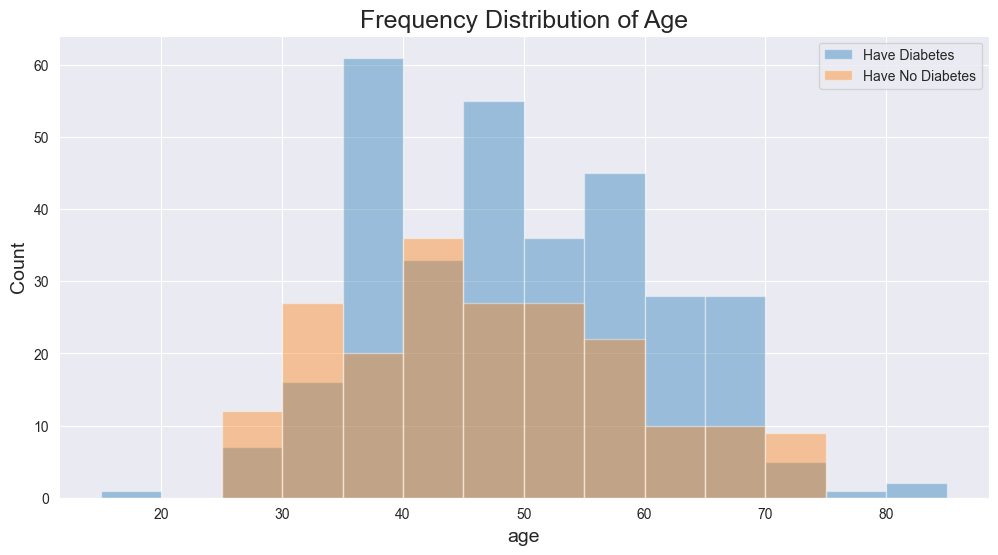

In [83]:
plt.figure(figsize=(12,6))
plt.hist(diabetes_df[diabetes_df['class']=='Positive']['age'], alpha=0.4, bins=np.arange(15, 90, 5),label='Have Diabetes')
plt.hist(diabetes_df[diabetes_df['class']=='Negative']['age'], alpha=0.4, bins=np.arange(15, 90, 5),label='Have No Diabetes')
plt.title('Frequency Distribution of Age',fontsize=18)
plt.xlabel('age',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.legend();
plt.show()


In [84]:
diabetes_df[(diabetes_df['class']=='Positive') & ((diabetes_df['age']<=20) | (diabetes_df['age']>=75))]

,age,gender,polyuria,polydipsia,sudden weight loss,weakness,polyphagia,genital thrush,visual blurring,itching,irritability,delayed healing,partial paresis,muscle stiffness,alopecia,obesity,class
101,85,Male,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,No,Positive
102,90,Female,No,Yes,Yes,No,No,Yes,Yes,Yes,No,No,No,Yes,Yes,No,Positive
113,79,Male,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,No,Yes,No,No,No,Positive
133,16,Male,Yes,No,Yes,No,Yes,No,No,No,No,No,No,No,No,No,Positive
185,85,Male,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,No,Positive
186,90,Female,No,Yes,Yes,No,No,Yes,Yes,Yes,No,No,No,Yes,Yes,No,Positive


### Based on the frequency distribution of age, we found out that most of people who have diabetes have age of 35-39. There are also patients who aged of 16 as well as between 75 and 90 in the dataset. 
### Based on the extraction of data above, it is found that all of these minority patients sufferred from sudden weight loss and did not suffer from obesity. Hence, it is suspected that sudden weight loss would be an important variable in the diabetes detection analysis, and vice versa for the obesity variable. However, it requires further analysis to confirm these relationships.

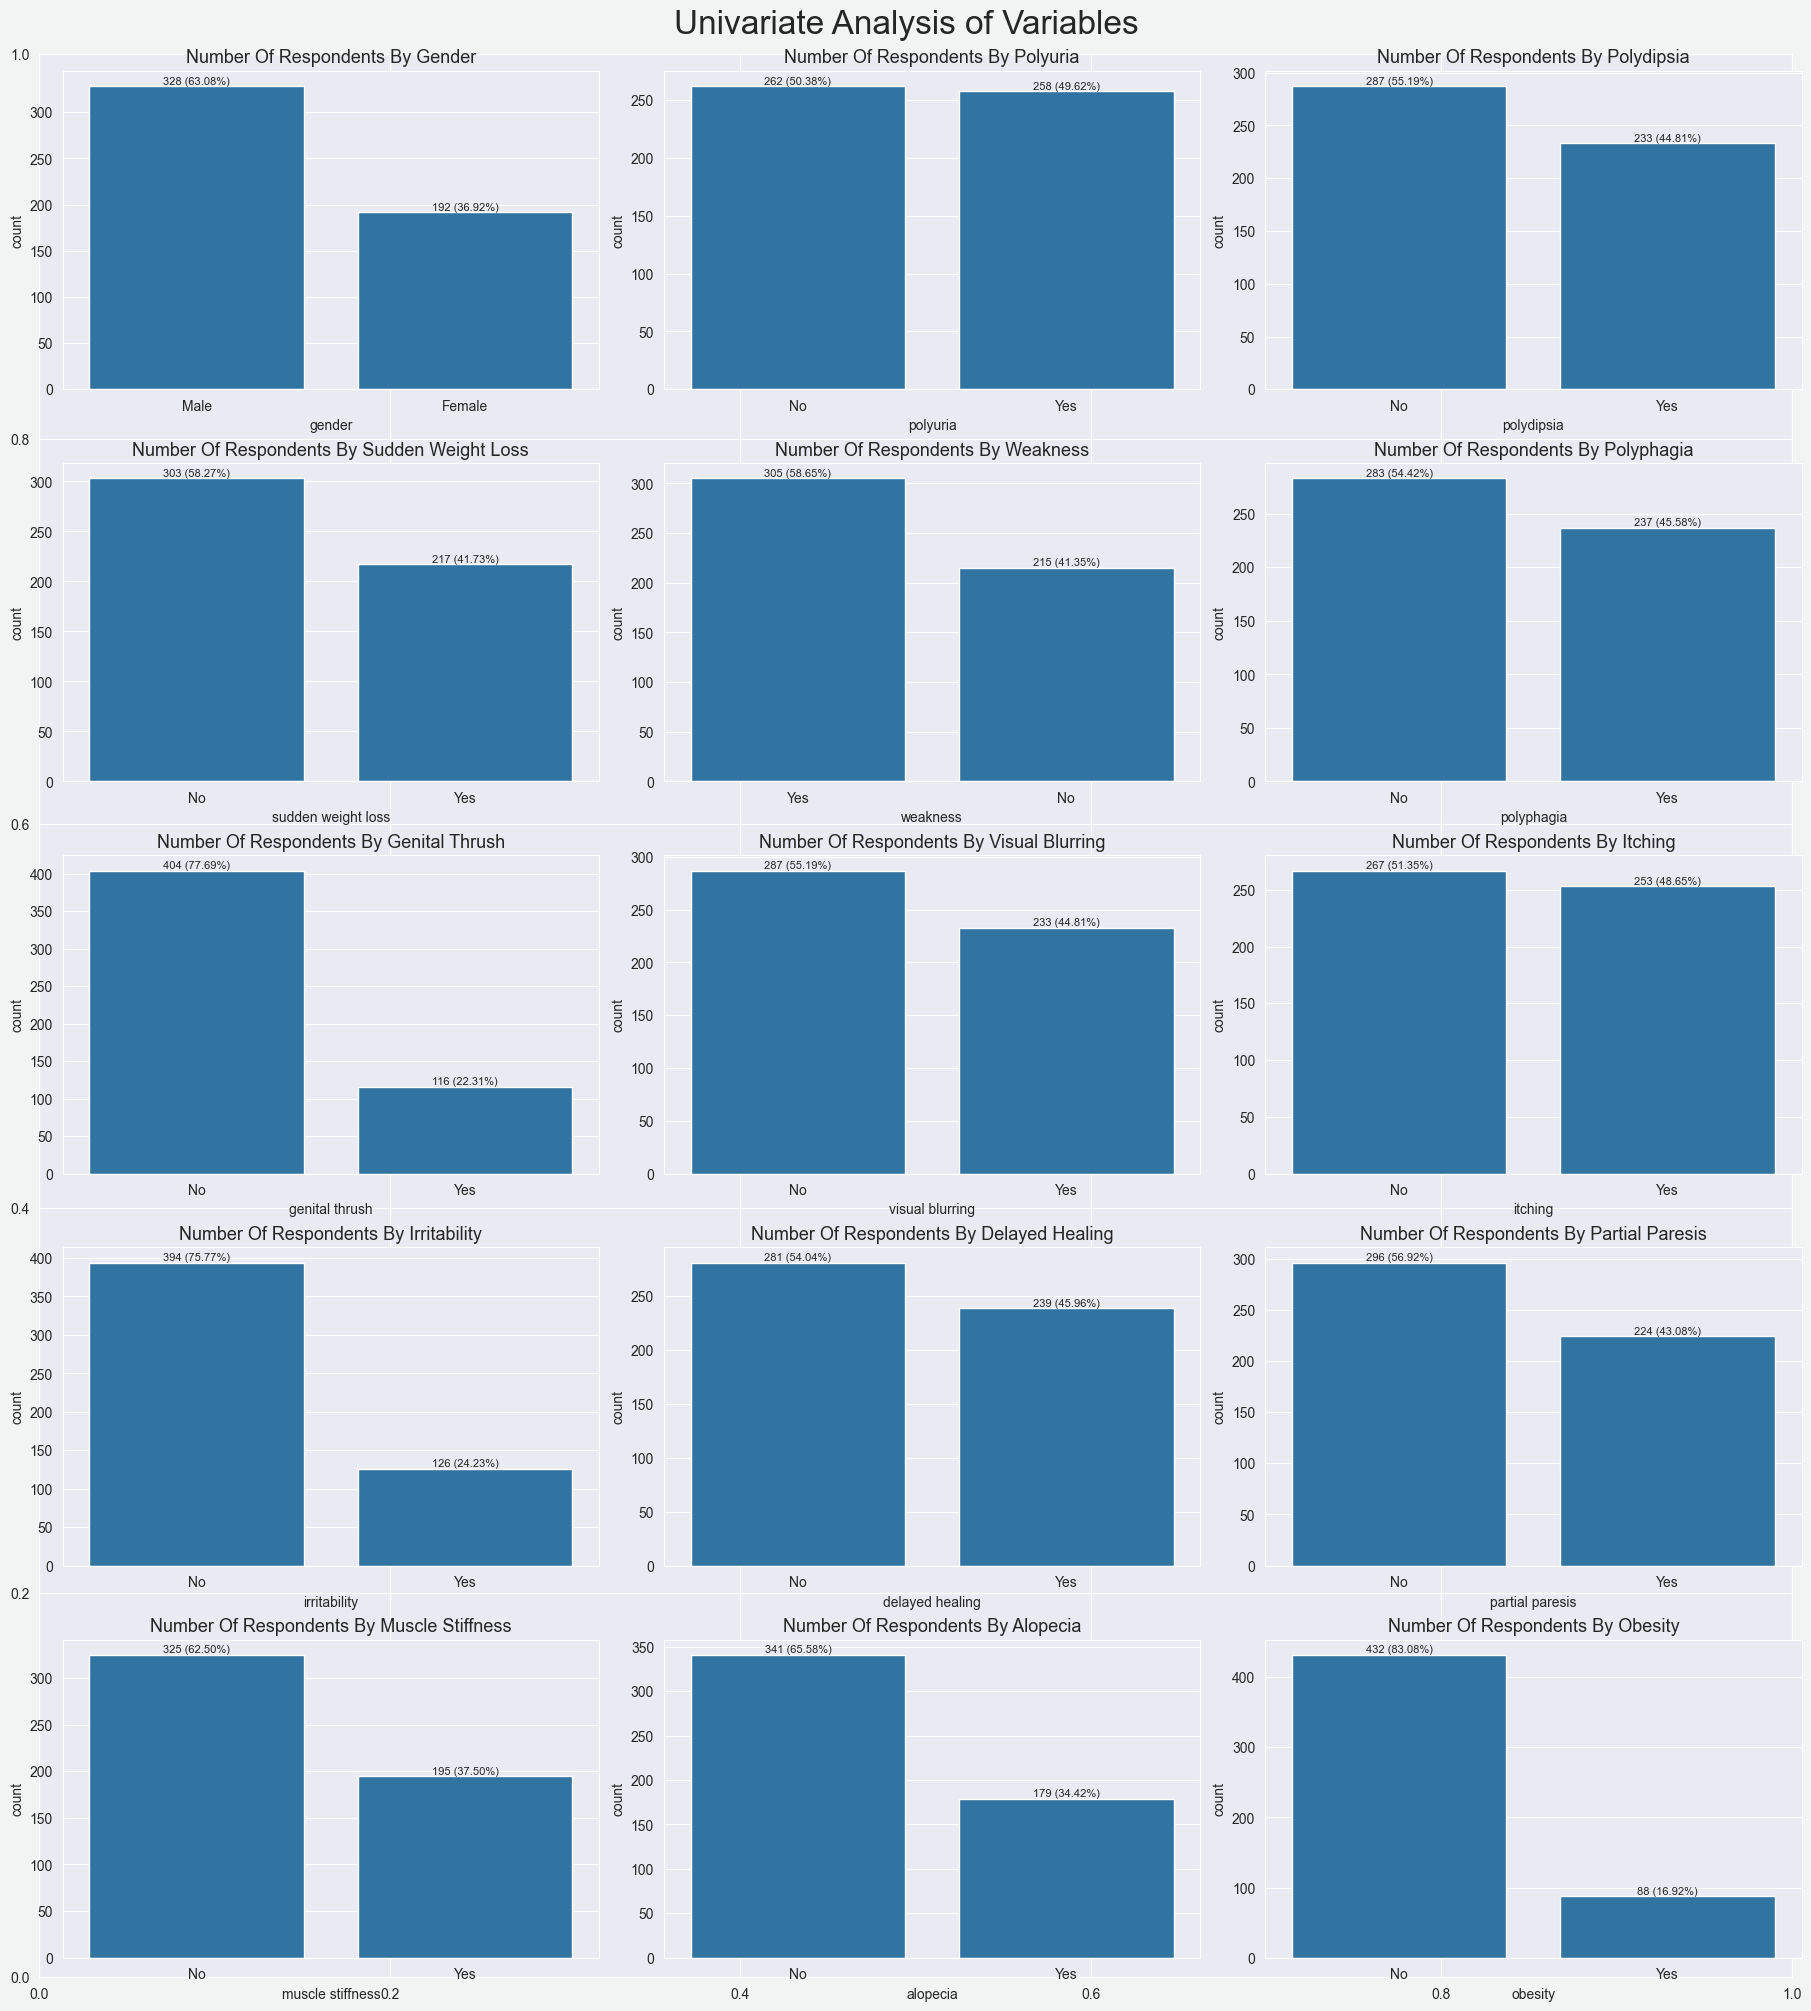

In [85]:
fig, ax = plt.subplots(figsize=(18,20), facecolor='#F2F4F4', constrained_layout=True)

count = 1

for i in diabetes_df.columns[1:-1]:
    plt.subplot(5, 3, count)
    
    abs_val = diabetes_df[i].value_counts()
    rel_val = diabetes_df[i].value_counts(normalize=True).values * 100
    
    
    a = sns.countplot(x=diabetes_df[i], order=abs_val.index)
    
    # Labels
    lbs_val = [f"{v} ({p:.2f}%)" for v, p in zip(abs_val, rel_val)]
    a.bar_label(a.containers[0], labels=lbs_val, fontsize=8)
    
    plt.title(('Number of respondents by ' + i).title(), fontsize=13)
    
    count += 1

plt.suptitle('Univariate Analysis of Variables', fontsize=24)
plt.show()

# Multivariate Analysis & Hypothesis Testing

In [86]:
labelencoder = LabelEncoder()
for i in diabetes_df[1:]:
    diabetes_df[i] = labelencoder.fit_transform(diabetes_df[i])

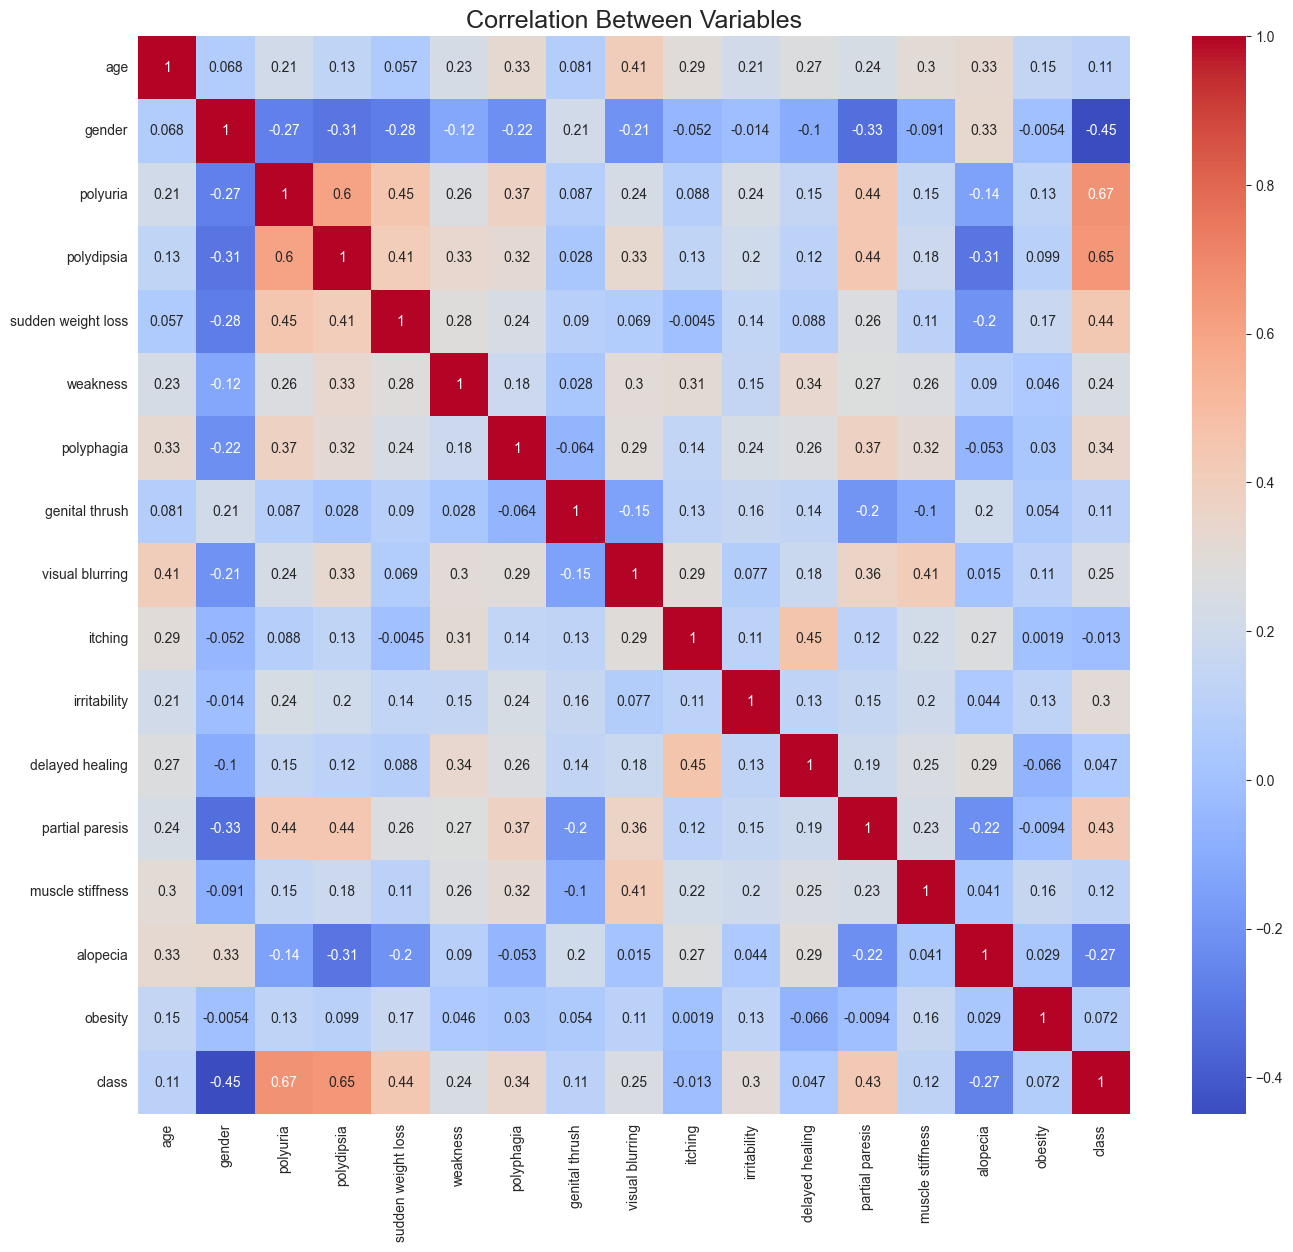

In [87]:
plt.figure(figsize = (16,14))
sns.heatmap(diabetes_df.corr(), annot=True, fmt='.2g',cmap='coolwarm')
plt.title('Correlation Between Variables', fontsize=18);
plt.show()

In [88]:
diabetes_obesity_crosstab = pd.crosstab(diabetes_df['obesity'], diabetes_df['class'])
Chisquares_diabetes_obesity = stats.chi2_contingency(diabetes_obesity_crosstab)
Chisquares_diabetes_obesity

Chi2ContingencyResult(statistic=np.float64(2.327473958333334), pvalue=np.float64(0.12710799319896815), dof=1, expected_freq=array([[166.15384615, 265.84615385],
       [ 33.84615385,  54.15384615]]))

### The chi-squared test between obesity & diabetes status showed that p-value = 0.13 > 0.05. 
### Hence, we cannot reject the null hypothesis and we cannot say that there is no significant relationship between obesity & diabetes. For this reason, I would exclude obesity from the model building.

In [89]:
gender_obesity_crosstab = pd.crosstab(diabetes_df['gender'], diabetes_df['class'])
Chisquares_gender_obesity = stats.chi2_contingency(gender_obesity_crosstab)
Chisquares_gender_obesity

Chi2ContingencyResult(statistic=np.float64(103.03685927972559), pvalue=np.float64(3.289703730553294e-24), dof=1, expected_freq=array([[ 73.84615385, 118.15384615],
       [126.15384615, 201.84615385]]))

### The chi-squared test between gender & diabetes status showed that p-value = 3.29e-24 < 0.05
### Hence, we can reject the null hypothesis and we can say that there is a significant relationship between gender & diabetes.

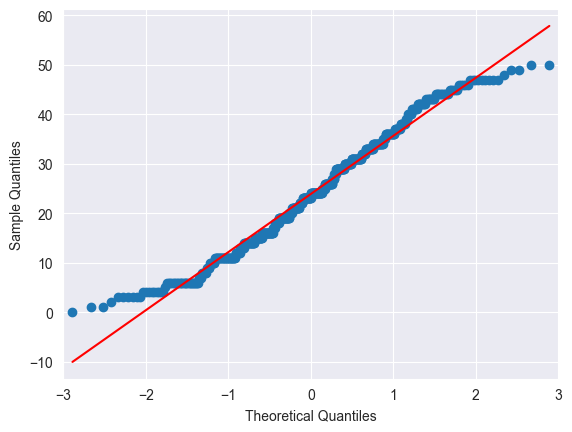

In [90]:
qqplot(diabetes_df['age'],line='s')
plt.show()

In [91]:
stats.shapiro(diabetes_df['age']) 

ShapiroResult(statistic=np.float64(0.9785804090910089), pvalue=np.float64(6.470166070588486e-07))

### Based on the qqplot (most points lied on the line) and the Shapiro result which showed that the p-value = 6.47e-07 < 0.05
### We can say that the distribution of the age is NOT normally distributed, hence z-test cannot be conducted.

In [92]:
diabetes_df=pd.read_csv("C:\\Users\\tanis\\Downloads\\diabetes_data_upload.csv")
diabetes_df.columns = diabetes_df.columns.str.lower()

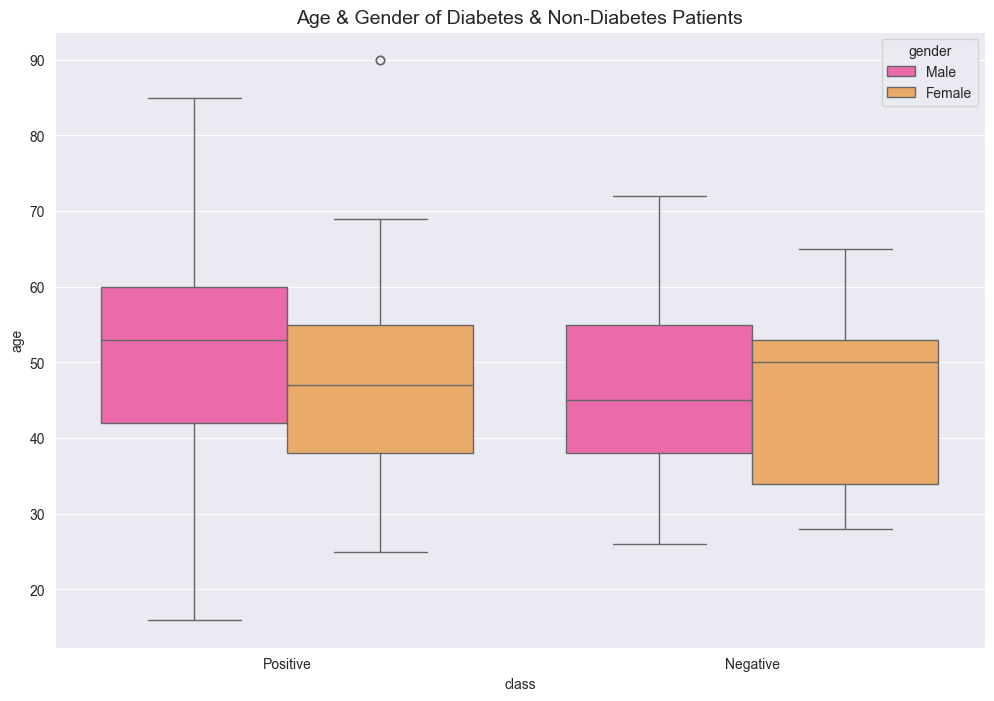

In [93]:
plt.figure(figsize=(12,8))
a = sns.boxplot(y='age', x='class', hue='gender',data=diabetes_df, palette='spring')
plt.title("Age & Gender of Diabetes & Non-Diabetes Patients", fontsize=14);
plt.show()



# Model Building & Evaluation

In [94]:
X = diabetes_df.drop(['class','obesity'], axis=1)
Y = diabetes_df['class'].map({'Negative':0,'Positive':1})

In [95]:
num_cols = ['age']
cat_cols = list(X.drop(['age'], axis=1))

full_pipeline = ColumnTransformer([
    ("num", MinMaxScaler(), num_cols),
    ("cat", OneHotEncoder(sparse_output=False, dtype=int, drop="if_binary"), cat_cols)
])

In [96]:
# Create training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42, stratify=Y)

In [97]:
X_train = full_pipeline.fit_transform(X_train)
X_test = full_pipeline.transform(X_test)

In [98]:
classifiers = []
log_reg = LogisticRegression(max_iter=10000)
classifiers.append(log_reg)
knn_neg = KNeighborsClassifier(metric='euclidean') 
classifiers.append(knn_neg)
dt_model = DT(random_state=42)
classifiers.append(dt_model)
rf_model = RF(random_state=42)
classifiers.append(rf_model)
ab_model=AdaBoostClassifier(random_state=42)
classifiers.append(ab_model)
xgb_model = XGBClassifier(random_state=42)
classifiers.append(xgb_model)
GNB_model = GB() 
classifiers.append(GNB_model)
SVM_model = SVC(random_state=42)
classifiers.append(SVM_model)
classifiers

[LogisticRegression(max_iter=10000),
 KNeighborsClassifier(metric='euclidean'),
 DecisionTreeClassifier(random_state=42),
 RandomForestClassifier(random_state=42),
 AdaBoostClassifier(random_state=42),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...),
 GaussianNB(),
 SVC(rando

In [99]:
recall_train = []
recall_test = []
for clf in classifiers:
    clf.fit(X_train, Y_train)
    pred_train = clf.predict(X_train)
    pred_test = clf.predict(X_test)
    rn = round(recall_score(Y_train, pred_train, average='macro')*100,2)
    rt = round(recall_score(Y_test, pred_test, average='macro')*100,2)
    recall_train.append(rn)
    recall_test.append(rt)

In [100]:
original_result = pd.DataFrame(data={'Model':['LR','KNN','DT','RF','AdaBoost','XGB','Gaussian Bayes','SVM'],
                                     'Recall-Macro_Training (%)':recall_train,
                                     'Recall-Macro_Test (%)':recall_test})
original_result.sort_values(by=['Recall-Macro_Test (%)'],ascending=False)

,Model,Recall-Macro_Training (%),Recall-Macro_Test (%)
3,RF,100.00,98.00
5,XGB,100.00,97.75
2,DT,100.00,96.38
7,SVM,97.92,95.50
4,AdaBoost,93.92,93.62
1,KNN,95.92,92.62
0,LR,95.04,92.00
6,Gaussian Bayes,89.79,90.62


### From the results above, it is clearly seen that the decision tree, random forest and xgb models have **overfitting** problems, as they are unable to generalize well and they only outperform when training data is used. To avoid overfitting problem, **cross-validation** is performed in the following step.

In [101]:
rc_mean_cv = []
rc_std_cv = []
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for i in classifiers:
    score = cross_val_score(i,X_train,Y_train,scoring='recall_macro', cv=kf)
    rc_mean_cv.append(round(score.mean()*100,2))
    rc_std_cv.append(round(score.std()*100,2))

In [102]:
cv_result = pd.DataFrame(data={'Model':['LR','KNN','DT','RT','AdaBoost','XGB','GNB','SVM'],
                               'Recall-Macro_Mean(%)':rc_mean_cv,
                               'Recall-Macro_SDev(%)':rc_std_cv})
cv_result.sort_values(['Recall-Macro_Mean(%)','Recall-Macro_SDev(%)'],ascending=False)

,Model,Recall-Macro_Mean(%),Recall-Macro_SDev(%)
3,RT,96.75,2.31
5,XGB,95.92,2.38
7,SVM,95.67,1.78
2,DT,95.46,2.82
1,KNN,94.75,1.52
0,LR,94.42,0.98
4,AdaBoost,91.62,2.49
6,GNB,89.46,1.88


### Based on the cross-validation result above, only SVC, decision tree and random forest classifiers have recall of more than or equal to 96%. 
### However, the decision tree classifier is doing a better job than the SVC and random forest classifiers as it has lower standard deviation (how much the predicted value differ from the actual value). 

## Handling imbalanced class with SMOTE-based techniques

In [103]:
diabetes_df['class'].value_counts()

class
Positive    320
Negative    200
Name: count, dtype: int64

## There is imbalanced class in the dataset, where the majority class belongs to the “0” (we denoted it as negative) label and the minority class belongs to the “1” (we denoted it as positive) label. 
## Hence, SMOTE based techniques (`SMOTE`, `ADASYN`, `SMOTEENN`, `SMOTETomek`) would be used to overcome this issue on the SVM. 

In [105]:
# SMOTE

counter = Counter(Y_train)
print('Before', counter)
smt = SMOTE(random_state=42)
X_train_sm, Y_train_sm = smt.fit_resample(X_train, Y_train)
counter = Counter(Y_train_sm)
print('After', counter)

Before Counter({1: 240, 0: 150})
After Counter({1: 240, 0: 240})


In [106]:
# ADASYN
counter = Counter(Y_train)
print('Before', counter)
ada = ADASYN(random_state=42)
X_train_ada, Y_train_ada = ada.fit_resample(X_train, Y_train)
counter = Counter(Y_train_ada)
print('After', counter)

Before Counter({1: 240, 0: 150})
After Counter({1: 240, 0: 237})


In [107]:
# SMOTE-ENN
counter = Counter(Y_train)
print('Before', counter)
smenn = SMOTEENN(random_state=42)
X_train_smenn, Y_train_smenn = smenn.fit_resample(X_train, Y_train)
counter = Counter(Y_train_smenn)
print('After', counter)

Before Counter({1: 240, 0: 150})
After Counter({0: 232, 1: 215})


In [108]:
# SMOTE-TOMEK
counter = Counter(Y_train)
print('Before', counter)
smtom = SMOTETomek(random_state=42)
X_train_smtom, Y_train_smtom = smtom.fit_resample(X_train, Y_train)
counter = Counter(Y_train_smtom)
print('After', counter)

Before Counter({1: 240, 0: 150})
After Counter({1: 239, 0: 239})


### Above are the SMOTE-based techniques to be used to handle imbalanced data. 
### Below is the function which involved: 
### 1. Pipeline to handle the inbalanced dataset, scale the data, and run the data with a set of classifiers one by one. 
### 2. Hyperparameter tuning process with 5-fold cross validation for each classifier to select the best model and its best parameters with the
### `PipelineHelper`. 

In [109]:
def diabetes_prediction(X, Y, smote=False, adasyn=False, smote_enn=False, smote_tomek=False):
    
    # Train Test Split
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.25, random_state=42, stratify=Y
    )
    
    # Preprocessing
    trf = ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(sparse_output=False, drop='first'),
         ['gender','polyuria','polydipsia','sudden weight loss',
          'weakness','polyphagia','genital thrush','visual blurring',
          'itching','irritability','delayed healing','partial paresis',
          'muscle stiffness','alopecia']),
        
        ('num', MinMaxScaler(), ['age'])
    ])
    
    # Choose ONE model (recommended for stability)
    model = SVC(random_state=42)
    
    # Pipeline selection based on sampling
    if smote:
        pipeline = imbpipeline([
            ('preprocessing', trf),
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ])
        
    elif adasyn:
        pipeline = imbpipeline([
            ('preprocessing', trf),
            ('adasyn', ADASYN(random_state=42)),
            ('classifier', model)
        ])
        
    elif smote_enn:
        pipeline = imbpipeline([
            ('preprocessing', trf),
            ('smoteenn', SMOTEENN(random_state=42)),
            ('classifier', model)
        ])
        
    elif smote_tomek:
        pipeline = imbpipeline([
            ('preprocessing', trf),
            ('smotetomek', SMOTETomek(random_state=42)),
            ('classifier', model)
        ])
        
    else:
        pipeline = imbpipeline([
            ('preprocessing', trf),
            ('classifier', model)
        ])
    
    # Cross Validation
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    scores = cross_val_score(pipeline, X_train, Y_train, cv=kf, scoring='recall_macro')
    
    # Train model
    pipeline.fit(X_train, Y_train)
    
    # Test score
    test_score = pipeline.score(X_test, Y_test)
    
    print(f"Cross-validation score: {round(scores.mean()*100,2)}%")
    print(f"Test score: {round(test_score*100,2)}%")

In [110]:
diabetes_prediction(X, Y, smote=True)

Cross-validation score: 95.67%
Test score: 94.62%


In [111]:
%%time
diabetes_prediction(X,Y,smote=True,adasyn=False,smote_enn=False,smote_tomek=False)

Cross-validation score: 95.67%
Test score: 94.62%
CPU times: total: 141 ms
Wall time: 127 ms


In [112]:
%%time
diabetes_prediction(X,Y,smote=False,adasyn=True,smote_enn=False,smote_tomek=False)

Cross-validation score: 95.54%
Test score: 96.15%
CPU times: total: 156 ms
Wall time: 175 ms


In [113]:
%%time
diabetes_prediction(X, Y, smote=False,adasyn=False,smote_enn=True,smote_tomek=False)

Cross-validation score: 92.75%
Test score: 93.85%
CPU times: total: 156 ms
Wall time: 143 ms


In [114]:
%%time
diabetes_prediction(X, Y, smote=False,adasyn=False,smote_enn=False,smote_tomek=True)

Cross-validation score: 95.67%
Test score: 95.38%
CPU times: total: 172 ms
Wall time: 157 ms


In [115]:
%%time
diabetes_prediction(X, Y, smote=False,adasyn=False,smote_enn=False,smote_tomek=False)

Cross-validation score: 95.67%
Test score: 95.38%
CPU times: total: 141 ms
Wall time: 139 ms


### It is always recommended for us to treat the imbalanced data beforehand, to avoid degradation of model performance; hence, the <b> SVM model with SMOTE-ENN technique </b> is chosen as the <b>final model</b> as the difference between its cross-validation score and testing score is the smallest. 

# Final Model Selection

In [128]:
%%time

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=42, stratify=Y
)

cat_cols = list(X.drop(['age'], axis=1))

preprocess = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(sparse_output=False, dtype=int, drop="if_binary"), cat_cols),
    ('num', MinMaxScaler(), ['age'])
], remainder='passthrough')

final_pipeline = imbpipeline(steps=[
    ('preprocessing', preprocess),
    ('smote_enn', SMOTEENN(random_state=42)),
    ('SVM_model', SVC(random_state=42))
])

param_grid = [{
    'SVM_model__C': [0.2, 0.4, 0.6, 0.8, 1.0],
    'SVM_model__kernel': ['linear', 'rbf'],
    'SVM_model__gamma': [1, 0.1, 0.01, 0.001, 0.0001]
}]

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    final_pipeline,
    param_grid,
    cv=kf,
    scoring='recall_macro',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)

final_model = grid_search.best_estimator_
cv_score = grid_search.best_score_
test_score = grid_search.score(X_test, Y_test)

print(f'Cross-validation score: {round(cv_score*100,2)}%')
print(f'Test score: {round(test_score*100,2)}%')

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Cross-validation score: 95.38%
Test score: 95.75%
CPU times: total: 734 ms
Wall time: 3.75 s


In [129]:
final_model

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                dtype=<class 'int'>,
                                                                sparse_output=False),
                                                  ['gender', 'polyuria',
                                                   'polydipsia',
                                                   'sudden weight loss',
                                                   'weakness', 'polyphagia',
                                                   'genital thrush',
                                                   'visual blurring', 'itching',
                                                   'irritability',
                                                   'delayed healing',
                                                   'partial paresis',
                                                   'muscle stiffness',
                                                   'alopecia']),
                                                 ('num', MinMaxScaler(),
                                                  ['age'])])),
                ('smote_enn', SMOTEENN(random_state=42)),
                ('SVM_model', SVC(C=0.4, gamma=1, random_state=42))])

In [130]:
pred_train = final_model.predict(X_train)
pred_test = final_model.predict(X_test)
recall_train = round(recall_score(Y_train, pred_train, average='macro')*100,2)
recall_test = round(recall_score(Y_test, pred_test, average='macro')*100,2)
print("Recall score from the final model (training data): ",recall_train,"%")
print("Recall score from the final model (testing data): ",recall_test,"%") 

Recall score from the final model (training data):  97.79 %
Recall score from the final model (testing data):  95.75 %


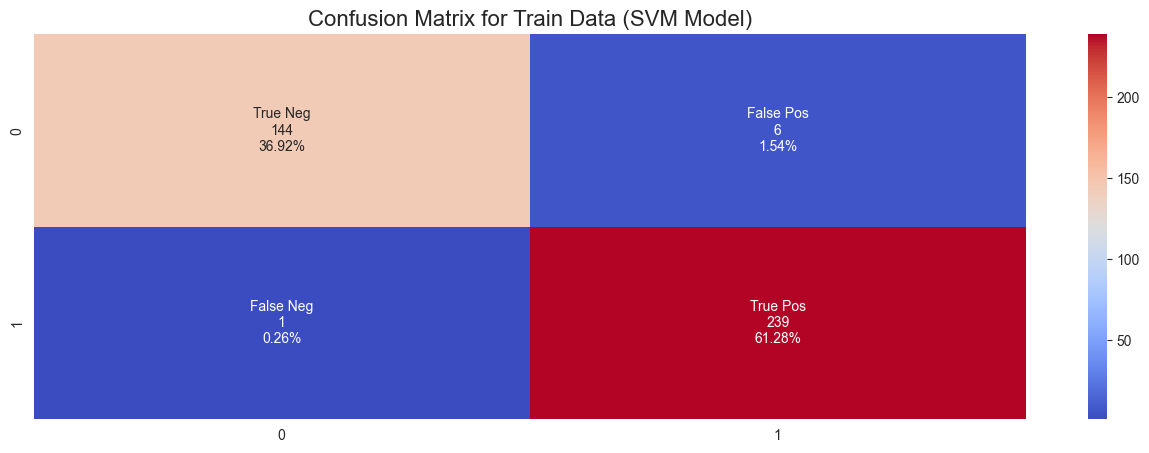

In [131]:
group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
train_cnf_matrix = confusion_matrix(Y_train,pred_train)
train_counts = ["{0:0.0f}".format(value) for value in train_cnf_matrix.flatten()]
train_percentage = ["{0:.2%}".format(value) for value in train_cnf_matrix .flatten()/np.sum(train_cnf_matrix)]
train_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,train_counts,train_percentage)]
train_labels = np.asarray(train_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(train_cnf_matrix, annot=train_labels, fmt='', cmap='coolwarm')
plt.title('Confusion Matrix for Train Data (SVM Model)',fontsize=16);
plt.show()

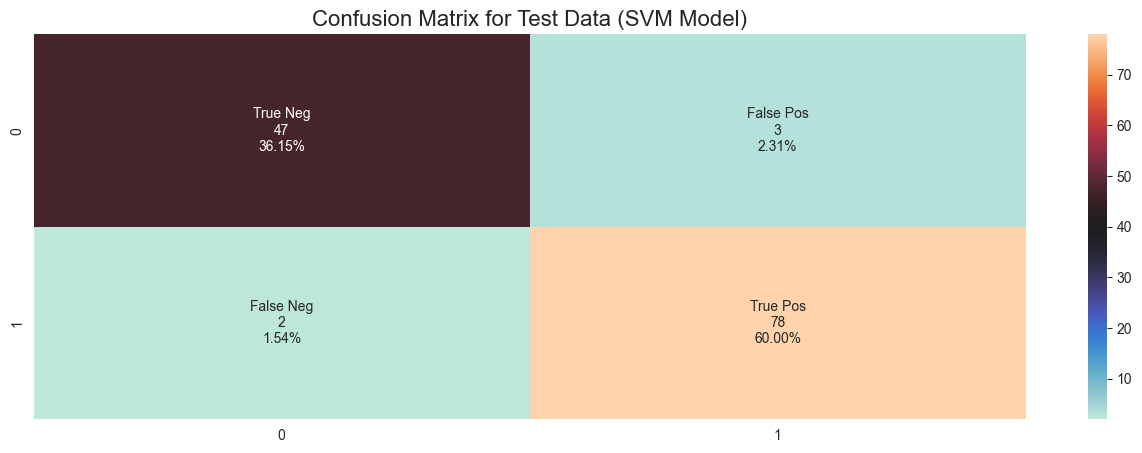

In [120]:
group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
test_cnf_matrix = confusion_matrix(Y_test,pred_test)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='icefire')
plt.title('Confusion Matrix for Test Data (SVM Model)',fontsize=16);
plt.show()

#### To predict who will likely to have diabetes, we prefer algorithms that can score a high probability of finding out people who have the same characteristics and actually have diabetes later (TRUE POSITIVE). 
#### Based on the severity of the illness, we may also prefer that the algorithm wrongly chooses some people who don’t get ill after all rather than miss the people who actually do get ill (FALSE POSITIVE). 

In [121]:
print(f"{classification_report(Y_train,pred_train)}")

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       150
           1       0.98      1.00      0.99       240

    accuracy                           0.98       390
   macro avg       0.98      0.98      0.98       390
weighted avg       0.98      0.98      0.98       390



In [122]:
print(f"{classification_report(Y_test,pred_test)}")

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        50
           1       0.96      0.97      0.97        80

    accuracy                           0.96       130
   macro avg       0.96      0.96      0.96       130
weighted avg       0.96      0.96      0.96       130



# Making Prediction With New Input

In [123]:
def predict(model, inputs):
    input_df = pd.DataFrame([inputs])
    pred = model.predict(input_df)[0]
    if pred == 0:
        print('It is predicted that this patient does not have diabetes.')
    else: 
        print('It is predicted that this patient would have diabetes.')

In [124]:
male_input = {'age':25, 
               'gender':'Male', 
               'polyuria':'No', 
               'polydipsia':'No', 
               'sudden weight loss':'No',   
               'weakness':'No', 
               'polyphagia':'No', 
               'genital thrush':'No', 
               'visual blurring':'Yes',     
               'itching':'No', 
               'irritability':'No', 
               'delayed healing':'No', 
               'partial paresis':'No',
               'muscle stiffness':'Yes', 
               'alopecia':'No'}

In [125]:
predict(final_model, male_input)

It is predicted that this patient does not have diabetes.


In [126]:
female_input = {'age':25, 
               'gender':'Female', 
               'polyuria':'No', 
               'polydipsia':'No', 
               'sudden weight loss':'No',   
               'weakness':'No', 
               'polyphagia':'No', 
               'genital thrush':'No', 
               'visual blurring':'Yes',     
               'itching':'No', 
               'irritability':'No', 
               'delayed healing':'No', 
               'partial paresis':'No',
               'muscle stiffness':'Yes', 
               'alopecia':'No'}

In [127]:
predict(final_model, female_input)

It is predicted that this patient would have diabetes.


# Recommendation

### * We could implement ensemble learning, such as by using voting classifier or stacking classifier.
### * Randomized Search could be used to tune the hyperparameters to see if the hyperparameter combination is the same.
### * If it is possible, we could increase the size of dataset by collecting more data. 

In [137]:
import pickle
import json

# Save the trained model
with open("final_diabetes_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("✅ Model saved as diabetes_model.pkl")

# Save the column names (X is your features dataframe)
feature_colums = list(X.columns)

with open("final_diabetes_features.json", "w") as f:
    json.dump(feature_colums, f)

print("✅ Features saved:", feature_colums)

with open("final_diabetes_model.pkl", "rb") as f:
    final_test_model = pickle.load(f)

with open("final_diabetes_features.json", "r") as f:
    final_test_features = json.load(f)

print("✅ Model loaded successfully")
print("✅ Features:", final_test_features)
print("✅ All good! Ready for PyCharm.")

✅ Model saved as diabetes_model.pkl
✅ Features saved: ['age', 'gender', 'polyuria', 'polydipsia', 'sudden weight loss', 'weakness', 'polyphagia', 'genital thrush', 'visual blurring', 'itching', 'irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'alopecia']
✅ Model loaded successfully
✅ Features: ['age', 'gender', 'polyuria', 'polydipsia', 'sudden weight loss', 'weakness', 'polyphagia', 'genital thrush', 'visual blurring', 'itching', 'irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'alopecia']
✅ All good! Ready for PyCharm.
